# AUC-ROC curve

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("E:/Dataset/diabetes.csv")

In [4]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
208,6,98,58,33,190,34.0,0.430,43,0
241,6,125,78,31,0,27.6,0.565,49,1
132,3,132,80,0,0,34.4,0.402,44,1
166,0,125,68,0,0,24.7,0.206,21,0
178,7,97,76,32,91,40.9,0.871,32,1


In [14]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [5]:
from sklearn.model_selection import train_test_split

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=17)

In [10]:
from sklearn.linear_model import LogisticRegression

In [11]:
log_reg = LogisticRegression(max_iter=1000)

In [17]:
log_reg.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
y_scores = log_reg.predict_proba(x_test)[:, 1]

In [21]:
y_scores  # Probability of a diabetes patient

array([0.44253018, 0.55958331, 0.92383508, 0.08071989, 0.11487084,
       0.26192843, 0.13383292, 0.12975318, 0.18221365, 0.20090015,
       0.07986952, 0.10827567, 0.54915373, 0.15365273, 0.33654953,
       0.81156408, 0.032082  , 0.06062088, 0.17929874, 0.08396841,
       0.59430454, 0.88412162, 0.05173012, 0.17770244, 0.10305286,
       0.05111012, 0.24422932, 0.30404989, 0.08484883, 0.55469579,
       0.14264025, 0.26858214, 0.16703642, 0.03211586, 0.01874948,
       0.09698184, 0.78490689, 0.02520746, 0.05896581, 0.09015758,
       0.05646007, 0.64728172, 0.18394706, 0.08292922, 0.05123223,
       0.04964049, 0.10021065, 0.18703121, 0.50228213, 0.08245157,
       0.0524295 , 0.16363379, 0.03687409, 0.2479954 , 0.39406485,
       0.17503288, 0.47629919, 0.05242315, 0.07395559, 0.25684619,
       0.04294933, 0.32674105])

### Finding FPR, TPR, and Threshold

In [22]:
from sklearn.metrics import roc_curve

In [23]:
fpr, tpr, threshold = roc_curve(y_test, y_scores)

In [26]:
threshold, fpr, tpr

(array([       inf, 0.92383508, 0.59430454, 0.55958331, 0.54915373,
        0.47629919, 0.44253018, 0.32674105, 0.26858214, 0.20090015,
        0.18703121, 0.18221365, 0.17929874, 0.17770244, 0.16703642,
        0.12975318, 0.11487084, 0.10827567, 0.10305286, 0.05896581,
        0.05646007, 0.01874948]),
 array([0.        , 0.        , 0.        , 0.02272727, 0.02272727,
        0.06818182, 0.06818182, 0.13636364, 0.13636364, 0.25      ,
        0.25      , 0.29545455, 0.29545455, 0.31818182, 0.31818182,
        0.43181818, 0.43181818, 0.45454545, 0.45454545, 0.72727273,
        0.72727273, 1.        ]),
 array([0.        , 0.05555556, 0.33333333, 0.33333333, 0.44444444,
        0.44444444, 0.5       , 0.5       , 0.61111111, 0.61111111,
        0.66666667, 0.66666667, 0.72222222, 0.72222222, 0.83333333,
        0.83333333, 0.88888889, 0.88888889, 0.94444444, 0.94444444,
        1.        , 1.        ]))

### Plotting the ROC curve

In [27]:
import plotly.graph_objects as go

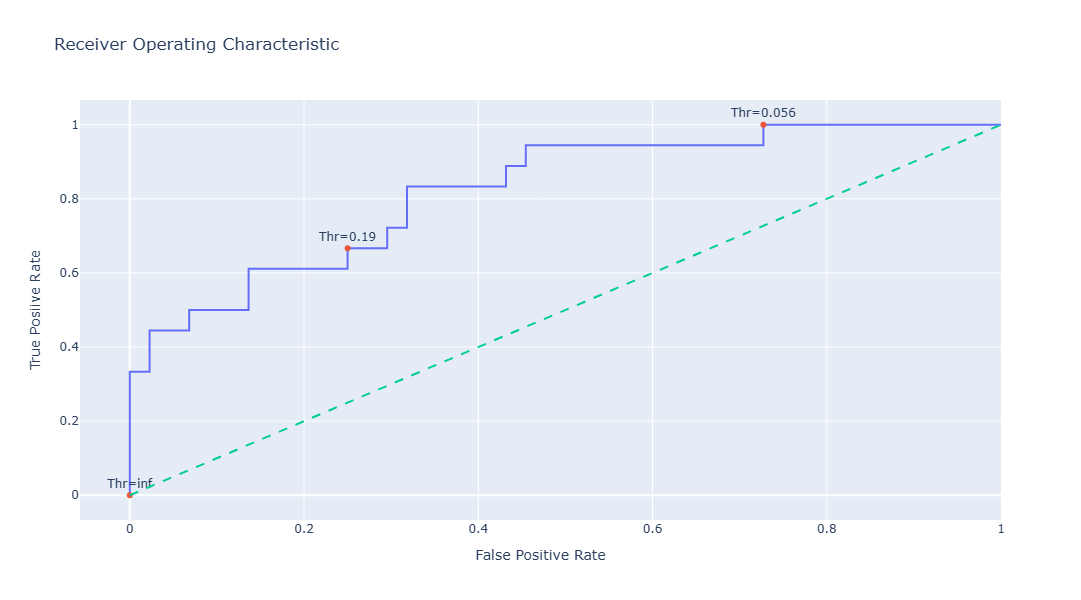

In [30]:
# Creating a trace for ROC curve

trace0 = go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC Curve')

# Only label every nth point to avoid clustering
n = 10
indices = np.arange(len(threshold)) % n == 0  # Choose indices where index mod n = 0

trace1 = go.Scatter(x=fpr[indices], y=tpr[indices], mode='markers+text', name='Threshold points',
                   text=[f"Thr={thr:.2}" for thr in threshold[indices]], textposition='top center')

# Diagonal line
trace2 = go.Scatter(x=[0,1], y=[0,1], mode='lines', name="Random (Area = 0.5)", line=dict(dash='dash'))

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(title='Receiver Operating Characteristic',
                  xaxis=dict(title='False Positive Rate'),
                  yaxis=dict(title='True Posiive Rate'),
                  autosize=False,
                  width=800, height=600,
                  showlegend=False)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

fig.show()

In [31]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = threshold[optimal_idx]
print("Optimal threshold is:", optimal_threshold)

Optimal threshold is: 0.16703641898264662
